#  Assignment 4: Double Descent in Linear Models

---

###  Zahra Khatibi - 53295A

---

This notebook investigates the **double descent** phenomenon in linear regression:

1. Generate synthetic linear regression data and implement **OLS** (ordinary least squares) and **Ridge** regression from scratch.
2. Sweep over feature dimension $d$ relative to sample size $n$ to observe the double descent curve.
3. Study the effect of **noise**, **regularisation** (Ridge), and **optimisation method** (gradient descent vs. closed form) on the phenomenon.

All source code are in the `src/` folder:

| Module | Purpose |
|--------|---------|
| `data.py` | Synthetic dataset generation |
| `ols.py` | Minimum-norm OLS solver |
| `ridge.py` | Ridge regression solver |
| `solvers.py` | Gaussian elimination, Householder-based SVD, the Moore–Penrose pseudoinverse, and linear regression weight fitting |
| `metrics.py` | MSE and weight-norm computation |
| `experiments.py` | comparing OLS, Ridge Regression, and Gradient Descent performance |
| `plotting.py` | All figure-generation functions |

---
## 1. The Double Descent Surprise

The test error curve is **not** U-shaped, it has **two descents** separated by a sharp peak.

**Why does the second descent happen?**  
When $d > n$ there are infinitely many weight vectors $w$ that perfectly fit the training data. OLS (via the pseudo-inverse) picks the unique one with **minimum norm**. As $d / n \to \infty$, each individual weight component becomes small and the solution approaches the true signal.


---
## 2. Implementation Overview

### 2.1 Data Generation (`data.py`)

```python
def generate_data(n, d, sigma, rng, n_test=2000):
    w_star = np.ones(d) / np.sqrt(d)          # unit-norm true weights
    X_train = rng.standard_normal((n, d))
    y_train = X_train @ w_star + rng.normal(0, sigma, n)
    X_test  = rng.standard_normal((n_test, d))
    y_test  = X_test  @ w_star + rng.normal(0, sigma, n_test)
    return X_train, y_train, X_test, y_test, w_star
```

Key choices:
- **$w^* = \mathbf{1}/\sqrt{d}$**: every feature carries equal signal; norm is always 1 regardless of $d$. This makes comparisons across dimensions fair.
- **$n_{\text{test}} = 2000$**: large test set gives low-variance MSE estimates.
- **Seeded RNG**: each $(d, \text{trial})$ pair uses a unique deterministic seed, guaranteeing full reproducibility.

### 2.2 OLS Solver (`ols.py`)

The ordinary least squares objective is $\min_w \|Xw - y\|^2$.  
We implement **two branches** depending on whether the problem is over- or under-determined:

* **Under-parameterised**
    * Condition: $d < n$
    * Formula: $\hat{w} = (X^\top X)^{-1} X^\top y$
    * Normal equations; unique solution

* **Over-parameterised**
    * Condition: $d \geq n$
    * Formula: $\hat{w} = X^\top (X X^\top)^{-1} y$
    * Dual form; **minimum-norm** solution

The **minimum-norm** solution in the over-parameterised case is the key to the second descent. It is equivalent to the Moore-Penrose pseudo-inverse: $\hat{w} = X^+ y$.

### 2.3 Ridge Regression (`ridge.py`)

Ridge adds an penalty to prevent the norm from growing:

$$\hat{w}_{\lambda} = \underset{w}{\arg\min} \|Xw - y\|^2 + \lambda \|w\|^2$$

Closed-form solutions (same two-branch logic):

* **Case:** $d \leq n$
    * Formula: $\hat{w} = (X^\top X + \lambda I_d)^{-1} X^\top y$

* **Case:** $d > n$
    * Formula: $\hat{w} = X^\top (X X^\top + \lambda I_n)^{-1} y$

Adding $\lambda I$ makes the matrix **strictly positive definite**, which:
- Eliminates the singularity at the interpolation threshold.
- Shrinks the weight vector towards zero.
- Trades additional bias for reduced variance.

### 2.4 Custom Linear Algebra (`solvers.py`)

To demonstrate the mechanics from scratch, `solvers.py` implements:

- **`solve(A, b)`**: Gaussian elimination with back-substitution (no pivoting). Solves $Aw = b$ for square $A$.
- **`_bidiagonalise(A)`**: Householder reflections that reduce $A$ to upper bidiagonal form $B = U_b A V_b$. This is the first stage of a full SVD.
- **`_householder_svd(A)`**: Full SVD via bidiagonalisation followed by `numpy`'s SVD on the small bidiagonal matrix.
- **`pinv(A)`**: Moore-Penrose pseudo-inverse using the custom SVD: $A^+ = V \Sigma^+ U^\top$, where singular values below a threshold are zeroed out.
- **`fit_weights(X, y)`**: Combines the above: normal equations when $d < n$, pseudo-inverse otherwise.


### 2.5 Metrics (`metrics.py`)

```python
compute_mse(w, X, y)       # mean squared error: mean((Xw - y)²)
compute_weight_norm(w)     # ℓ₂ norm of the weight vector: ‖w‖₂
```

---
## 3. Setup and Imports

In [6]:
import os
import sys
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

sys.path.insert(0, os.getcwd())

from src.experiments import (run_experiment, run_noise_sweep, run_gd_experiment)
from src.plotting import (fig1_ols_train_test, fig2_test_comparison, fig3_noise, fig4_weight_norm, 
                           fig5_gd, fig3_noise_individual, fig5_gd_comparison)

---
## 4. Experiment Parameters


| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n` | 100 | Number of training samples |
| `sigma` | 0.5 | Standard deviation of label noise |
| `n_trials` | 30 | Independent repetitions per $(d, \lambda)$ pair |
| `lambdas` | [0.1, 1, 10, 100] | Ridge regularisation strengths to compare |
| `d_values` | 10, 15, …, 300 | Feature dimensions swept (step = 5) |

The **interpolation threshold** occurs at $d = n = 100$. All error curves are clipped at 20 for visual clarity (the spike near $d = n$ can be arbitrarily large in individual trials).

Using 30 independent trials per point lets us plot **mean ± 1 standard deviation bands**, which shows how stable (or noisy) each method is.

In [7]:
n        = 100          # training samples
sigma    = 0.5          # noise level
n_trials = 30           # trials per d-value
lambdas  = [0.1, 1.0, 10.0, 100.0]  # ridge regularisation strengths
d_max    = 300
d_step   = 5
d_values = np.arange(10, d_max + 1, d_step)  # [10, 15, ..., 300]

outdir = "figures"
os.makedirs(outdir, exist_ok=True)

---
## 5. Main Experiment: 

We run three sweeps in sequence:

1. **Main experiment**, OLS + Ridge at all $\lambda$, with $\sigma = 0.5$.
2. **Noise sweep**, OLS only, varying $\sigma \in \{0.1, 0.5, 1.0\}$.
3. **Gradient descent comparison**, GD at several learning rates and epoch counts vs. closed-form OLS.

Each call to `run_experiment` loops over every $(d, \text{trial})$ pair, fits both OLS and all Ridge variants, and stores mean/std of train MSE, test MSE, and weight norm.

In [8]:
# Main experiment 
print("\nMain experiment (sigma=0.5)")
res = run_experiment(n, d_values, sigma, lambdas, n_trials)
print("==================================")
# Noise sweep
print("\nNoise sweep (sigma in {0.1, 0.5, 1.0})")
noise_results = run_noise_sweep(n, d_values, sigma_list=[0.1, 0.5, 1.0], lambdas=lambdas, n_trials=n_trials)
print("==================================")
# Gradient descent comparison 
print("\nGD comparison (lr=0.1, epochs=800)")
gd_mean, gd_std, cf_mean, cf_std = run_gd_experiment(n, d_values, sigma, n_trials=10, n_epochs=800, lr=0.1)


Main experiment (sigma=0.5)
  n=100, sigma=0.5, trials=30, d=[10,300], lambdas=[0.1, 1.0, 10.0, 100.0]
    d=  55  OLS test=0.5488 ±0.0724
    d= 105  OLS test=5.0490 ±2.4608
    d= 155  OLS test=1.0655 ±0.1174
    d= 205  OLS test=0.9939 ±0.0604
    d= 255  OLS test=1.0223 ±0.0637
    d= 300  OLS test=1.0479 ±0.0531

Noise sweep (sigma in {0.1, 0.5, 1.0})

[Noise sweep] sigma=0.1
  n=100, sigma=0.1, trials=30, d=[10,300], lambdas=[0.1, 1.0, 10.0, 100.0]
    d=  55  OLS test=0.0226 ±0.0044
    d= 105  OLS test=0.2435 ±0.1039
    d= 155  OLS test=0.3901 ±0.0527
    d= 205  OLS test=0.5444 ±0.0641
    d= 255  OLS test=0.6294 ±0.0520
    d= 300  OLS test=0.6833 ±0.0436

[Noise sweep] sigma=0.5
  n=100, sigma=0.5, trials=30, d=[10,300], lambdas=[0.1, 1.0, 10.0, 100.0]
    d=  55  OLS test=0.5651 ±0.1091
    d= 105  OLS test=4.7025 ±2.4377
    d= 155  OLS test=1.0622 ±0.1424
    d= 205  OLS test=1.0128 ±0.0855
    d= 255  OLS test=1.0271 ±0.0587
    d= 300  OLS test=1.0439 ±0.0553

[Noise 

---
## 6. Figure 1, OLS Train vs. Test Error (Double Descent)

### What to look for

This is the central result of the project. The plot shows:

- **Train MSE**: monotonically decreases as $d$ grows. For $d < n$. For $d \geq n$, train error drops to (near) **zero**.

- **Test MSE**: exhibits the classic **double descent** shape:
  1. *First descent* ($d < n$): more features reduce underfitting.
  2. *Peak* ($d \approx n$): the system is barely determined; the least-squares solution has huge coefficients and generalises poorly.
  3. *Second descent* ($d > n$): the minimum-norm solution spreads weight across many features; each coefficient is small and the model generalises well again.

### Why the peak is so sharp

At $d = n$, $X$ is square. For Gaussian random matrices, $X X^\top$ has its smallest eigenvalue close to zero with high probability. Inverting a near-singular matrix amplifies noise catastrophically. The test error can be **arbitrarily large** in single trials (hence the clipping at 20).

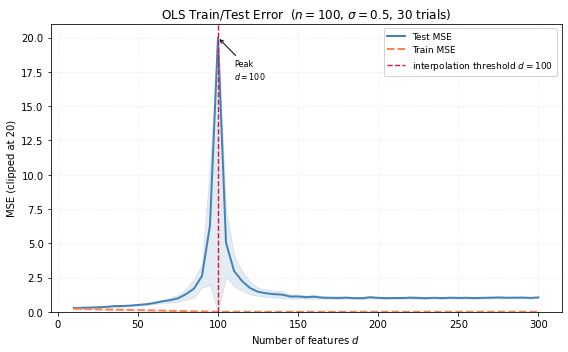

In [9]:
fig1_ols_train_test( d_values, n, res, sigma, outpath=os.path.join(outdir, "fig1_ols_train_test.png"))

---
## 7. Figure 2, OLS vs. Ridge: Effect of Regularisation

### What regularisation does

Ridge regression solves $\min_w \|Xw - y\|^2 + \lambda \|w\|^2$. The penalty $\lambda \|w\|^2$ has two key effects:

1. **Eliminates the singularity**: $(X^\top X + \lambda I)$ is always invertible, so there is no catastrophic peak at $d = n$.
2. **Keeps the weights small**: reduces variance at the cost of increased bias.

**Key insight**: Small $\lambda$ closely approximates OLS (low bias, high variance near threshold); large $\lambda$ is stable everywhere but underfits.

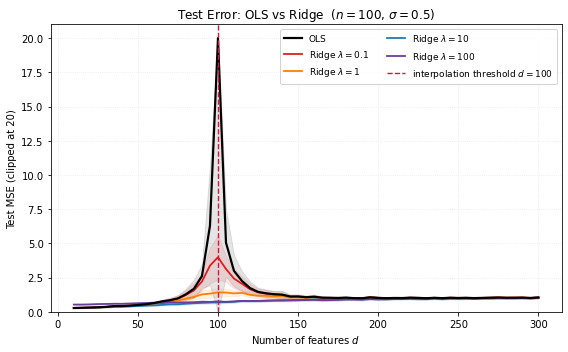

In [10]:
fig2_test_comparison(d_values, n, res, sigma, lambdas, outpath=os.path.join(outdir, "fig2_test_comparison.png"))

---
## 8. Figure 3, Effect of Noise Level on Double Descent

### How noise changes the picture

We sweep $\sigma \in \{0.1, 0.5, 1.0\}$ and plot OLS test MSE for each:

| $\sigma$ | Colour | Observation |
|----------|--------|-------------|
| 0.1 (low) | Dark green | Very low test error; the second descent is shallow because the signal is clean |
| 0.5 (medium) | Light green | Moderate error; clear double descent |
| 1.0 (high) | Red | High error; the peak is taller and the second descent is slower |

### Theoretical interpretation

In the over-parameterised regime, OLS test MSE scales roughly as $\sigma^2 \cdot n / (d - n)$. Higher $\sigma$ directly amplifies all MSE values and slows the recovery after the peak. The **shape** of the double descent curve is the same, but it is vertically scaled by noise.

The individual subplot version (`fig3_noise_individual`) makes it easy to see the exact peak height and recovery rate for each $\sigma$ on its own y-axis scale.

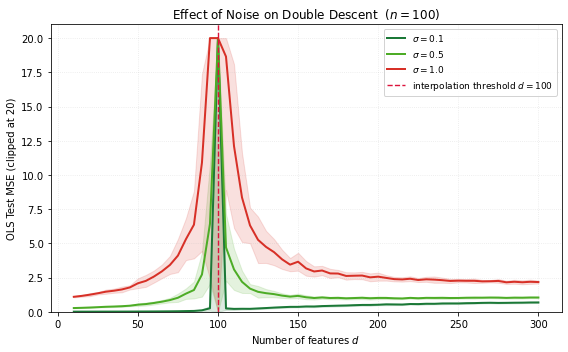

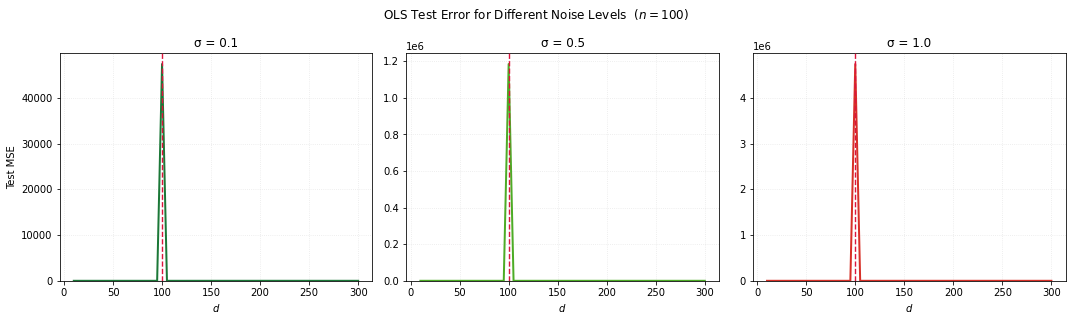

In [11]:
# overlaid comparison
fig3_noise(d_values, n, noise_results, outpath=os.path.join(outdir, "fig3_noise_overlay.png"))

# individual plots for each sigma
fig3_noise_individual(d_values, n, noise_results, outpath=os.path.join(outdir, "fig3_noise_individual.png"))

---
## 9. Figure 4, Weight Norm Analysis

### Why weight norm matters

The norm $\|\hat{w}\|_2$ tells us how large the model's coefficients are. Understanding how it behaves across the interpolation threshold explains *why* OLS generalises poorly near $d = n$ and recovers in the over-parameterised regime.

### OLS weight norm (left plot)

- For $d < n$: the problem is over-determined; the normal-equations solution has moderate norm.
- Near $d = n$: the matrix $X^\top X$ is nearly singular. To fit the data, the solver must produce a weight vector with **very large norm**, absorbing noise into large coefficients.
- For $d > n$: the minimum-norm pseudo-inverse solution is used. As $d$ grows, the norm **decreases**, the signal is spread over more features, so each coefficient shrinks. This explains the second descent: small-norm weights generalise better.

### Ridge weight norm (right plot)

The $\lambda \|w\|^2$ penalty explicitly penalises large norms:
- Larger $\lambda$ produces smaller norms for all $d$.
- The norm is always bounded, even at $d = n$, because the penalty prevents the blow-up.
- This directly links regularisation to generalisation: Ridge avoids the peak by preventing the norm from exploding.

When OLS weights become very large (around $d=n$), the test error also becomes very large. Ridge keeps the weights small, so the test error stays stable.

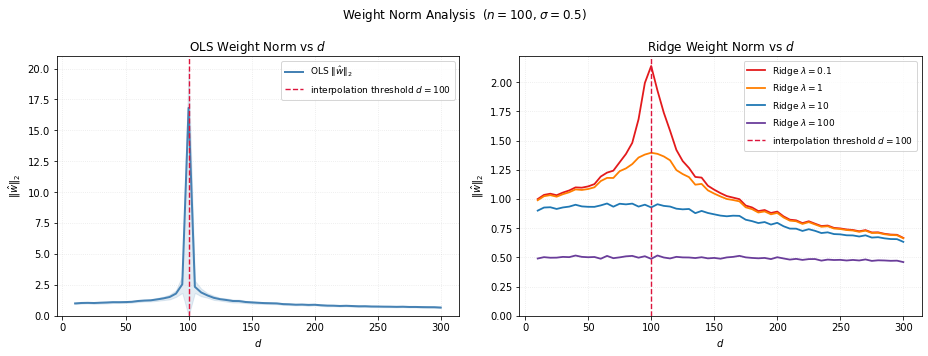

In [12]:
fig4_weight_norm(d_values, n, res, sigma, lambdas, outpath=os.path.join(outdir, "fig4_weight_norm.png"))

---
## 10. Figure 5,  Gradient Descent vs. Closed-Form OLS

### Why compare GD with the closed form?

In practice, neural networks are trained with gradient descent, not by inverting matrices. The question is: **does GD also exhibit double descent?**

The GD update rule for the linear MSE loss is:

$$w_{t+1} = w_t - \frac{\eta}{n} X^\top (X w_t - y)$$

Starting from $w_0 = \mathbf{0}$, gradient descent with small enough $\eta$ converges to:
- The **normal equations solution** when $d < n$ (same as closed form).
- The **minimum-norm solution** when $d > n$, the same target as closed-form OLS, because GD from zero is implicitly biased toward minimum-norm solutions in the span of $X^\top$.

### What to look for

- For $d < n$: GD and closed-form OLS should match closely (given enough iterations).
- At $d \approx n$: both spike, but GD may be slightly different because it hasn't fully converged.
- For $d > n$: GD should approximate the closed-form minimum-norm solution if the learning rate and number of epochs are sufficient.

**Early stopping as implicit regularisation**: if GD is stopped early (few epochs), it behaves similarly to Ridge with a large $\lambda$, it hasn't yet reached the minimum-norm interpolating solution, so norms stay small and generalisation can be better near the threshold.

The experiments below investigate the effect of both **learning rate** and **number of epochs**.

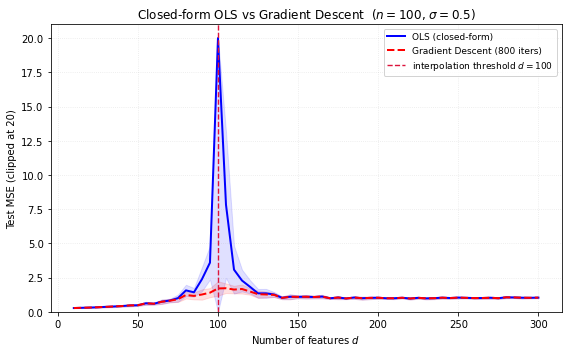

In [13]:
# basic GD vs closed-form OLS (lr=0.1, 800 epochs)
fig5_gd(d_values, n, gd_mean, gd_std, cf_mean, cf_std, sigma, outpath=os.path.join(outdir, "fig5_gd.png"))

### 10.1. Effect of Learning Rate

A larger learning rate converges faster but can overshoot or diverge. We compare several learning rates at a fixed number of epochs.

- **Small $lr$**: converges slowly; under-parameterised regime matches OLS, but over-parameterised regime may not have converged yet.
- **Medium $lr$**: good convergence; closely matches closed-form.
- **Large $lr$**: may diverge near the threshold where eigenvalues of $X^\top X / n$ are small (learning-rate stability requires $lr < 2n / \lambda_{\max}(X^\top X)$).


[GD] n_epochs=800, n_trials=4, lr=0.001

[GD] n_epochs=800, n_trials=4, lr=0.01

[GD] n_epochs=800, n_trials=4, lr=0.1


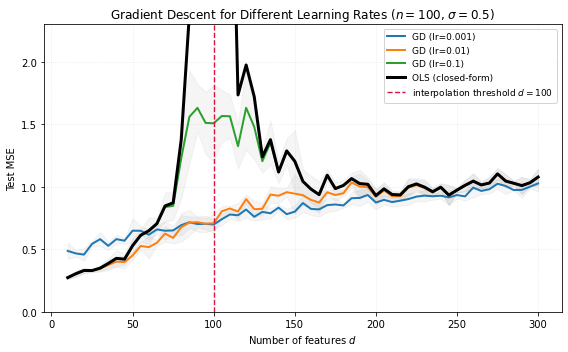

In [14]:
legend_label = "lr"
lr_list = [0.001, 0.01, 0.1]
results_lr = {}

for lr in lr_list:
    gd_m, gd_s, cf_m, cf_s = run_gd_experiment(n, d_values, sigma, n_trials=4, n_epochs=800, lr=lr)
    results_lr[lr] = (gd_m, gd_s)

fig5_gd_comparison(d_values, n, results_lr, cf_m, cf_s, sigma, legend_label,outpath=os.path.join(outdir, "fig5_lr_comparison.png"))

### 10.2. Effect of Number of Epochs

Fewer epochs means GD stops before reaching the minimum-norm interpolating solution.  
This is **early stopping**, an implicit form of regularisation.

- **Very few epochs (100)**: GD behaves similarly to Ridge with large $\lambda$; the norm is still small.
- **Many epochs (1000)**: GD approaches the closed-form OLS solution; the double descent peak emerges.

This is a practically important insight: neural networks trained with early stopping may partially avoid the double descent peak for the same reason.


[GD] n_epochs=100, n_trials=4, lr=0.1

[GD] n_epochs=500, n_trials=4, lr=0.1

[GD] n_epochs=800, n_trials=4, lr=0.1

[GD] n_epochs=1000, n_trials=4, lr=0.1


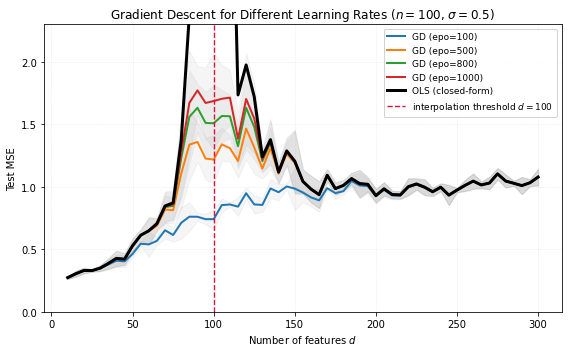

In [15]:
legend_label = "epo"
epochs_list = [100, 500, 800, 1000]
results_epo = {}

for epochs in epochs_list:
    gd_m, gd_s, cf_m, cf_s = run_gd_experiment(n, d_values, sigma, n_trials=4, n_epochs=epochs, lr=0.1)
    results_epo[epochs] = (gd_m, gd_s)

fig5_gd_comparison(d_values, n, results_epo, cf_m, cf_s, sigma,
                   legend_label, outpath=os.path.join(outdir, "fig5_epo_comparison.png"))

---
## 11. Summary and Key Takeaways


| Experiment | Main finding |
|------------|--------------|
| OLS train/test sweep | Clear double descent: test MSE peaks at $d = n$ then recovers |
| OLS vs Ridge | Ridge eliminates the peak by bounding the weight norm; optimal $\lambda$ beats OLS everywhere |
| Noise sweep | Double descent shape is universal; peak height and recovery rate scale with $\sigma^2$ |
| Weight norm | The test-error peak is directly caused by the norm blow-up at $d = n$ |
| GD comparison | GD converges to the same minimum-norm solution; early stopping acts like Ridge regularisation |
